## Load Data

In [33]:
#! pip install mne

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path
from utils import load_eeg_data, CHANNEL_GROUPS, FREQ_BANDS

# Define subjects for multi-subject analysis
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

CONDITION = "BLA"
CHANNELS = "BLA"   # T7, T8, TP7, TP8
FREQ_RANGE_LABEL = "delta_gamma"

import warnings
import contextlib
import io

all_epochs = {}
all_data = {}
loaded_subjects = []
failed_subjects = []

for SUBJECT_ID in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs = load_eeg_data(
                    CONDITION,
                    SUBJECT_ID,
                    channels=CHANNELS,
                    freq_band=FREQ_RANGE_LABEL
                )

        data = epochs.get_data() * 1e6
        all_epochs[SUBJECT_ID] = epochs
        all_data[SUBJECT_ID] = data
        loaded_subjects.append(SUBJECT_ID)

    except Exception as e:
        failed_subjects.append((SUBJECT_ID, str(e)))

print("Loaded successfully:", loaded_subjects)

if failed_subjects:
    print("\nFailed to load:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")

Loaded successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


## Frequency Domain Analysis - Multiple Subjects

Analyze the power spectral density (PSD) of BLA trials in different frequency bands across multiple subjects to understand oscillatory activity patterns.

Frequency bands:
- Delta: 0.5–4 Hz
- Theta: 4–8 Hz
- Alpha: 8–13 Hz
- Beta: 13–30 Hz
- Gamma: 30–45 Hz

**Subjects to analyze:** 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17 (14 subjects)

In [15]:
# Test the function import
from utils import compute_frequency_power, load_eeg_data
print("Functions imported successfully")

# Define subjects to analyze
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]  # All available BLA subjects
CONDITION = "BLA"
CHANNELS = "BLA"
ROLLING_WINDOW = 5  # trials in the moving average

print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")

Functions imported successfully
Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLA
Channels: BLA


In [36]:
import warnings
import contextlib
import io

all_power_dfs = {}
all_power_pivots = {}
all_psds_dicts = {}
processed_subjects = []
failed_subjects = []

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

for subject_id in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

        power_df, psds_dict = compute_frequency_power(epochs, fmin=0.5, fmax=45)

        power_pivot = (
            power_df.groupby(['trial', 'band'])['power']
            .mean()
            .unstack()
            .reindex(columns=bands)
        )

        all_power_dfs[subject_id] = power_df
        all_power_pivots[subject_id] = power_pivot
        all_psds_dicts[subject_id] = psds_dict
        processed_subjects.append(subject_id)

    except Exception as e:
        failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", processed_subjects)

if failed_subjects:
    print("\nFailed:")
    for subject_id, err in failed_subjects:
        print(f"Subject {subject_id}: {err}")


Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


# BLA Frequency Domain Absolute Power

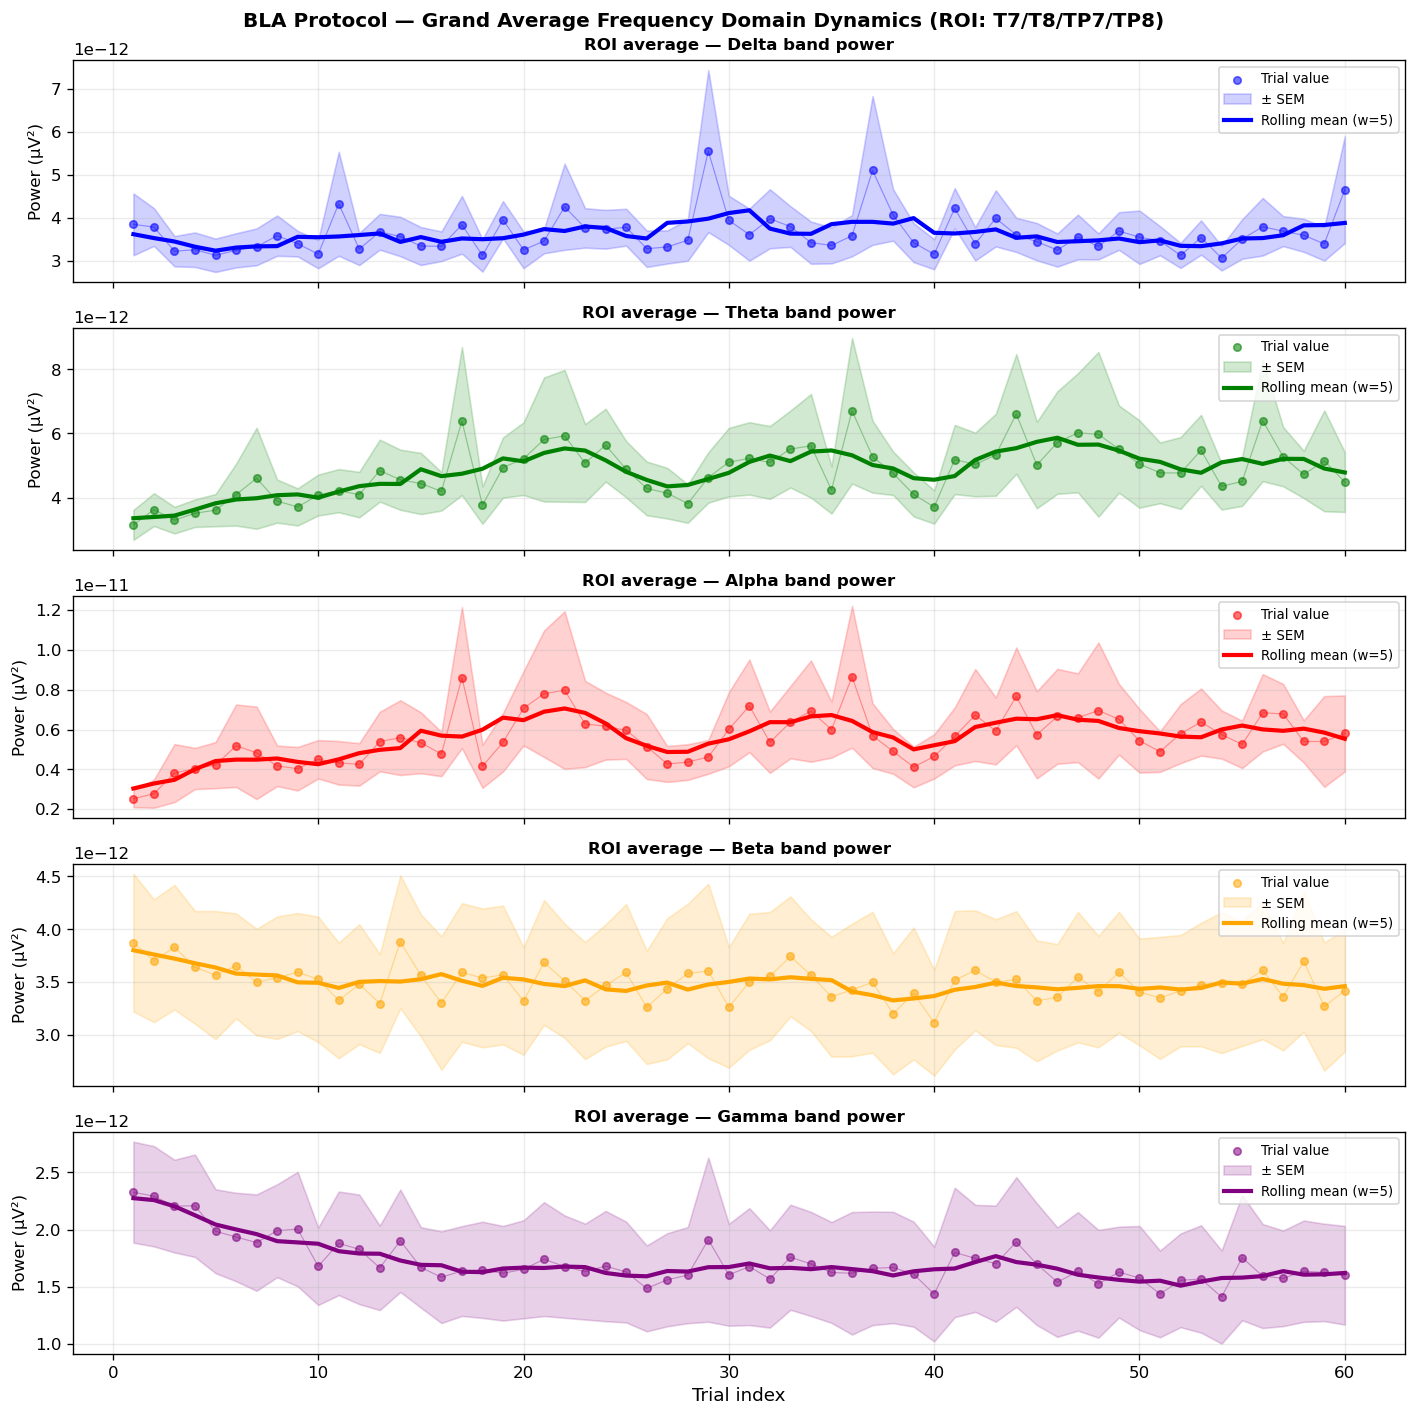

Figure saved: frequency_dynamics_BLA_grand_average.png
Analysis completed for subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Note: Grand average across all available BLA subject data files analyzed.


In [28]:
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

# build grand-average power table across subjects
grand_power = {}
grand_sem = {}

for band in bands:
    band_trials = []
    for subject_id in SUBJECTS:
        power_pivot = all_power_pivots[subject_id]
        if band in power_pivot.columns:
            band_trials.append(power_pivot[band].reset_index(drop=True))

    if band_trials:
        band_df = pd.concat(band_trials, axis=1)
        grand_power[band] = band_df.mean(axis=1)
        grand_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]
    if band in grand_power:
        values = grand_power[band].values
        errors = grand_sem[band].values
        trial_idx = np.arange(1, len(values) + 1)

        ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

        ax.fill_between(
            trial_idx,
            values - errors,
            values + errors,
            color=color,
            alpha=0.18,
            zorder=1,
            label='± SEM'
        )

        s = pd.Series(values)
        rolling = s.rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(trial_idx, rolling, color=color, linewidth=2.5, zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})')

    ax.set_ylabel('Power (µV²)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} band power', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(f'BLA Protocol — Grand Average Frequency Domain Dynamics (ROI: T7/T8/TP7/TP8)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: frequency_dynamics_BLA_grand_average.png")

print(f"Analysis completed for subjects: {SUBJECTS}")
print("Note: Grand average across all available BLA subject data files analyzed.")

# BLA Frequency Domain Relative Power

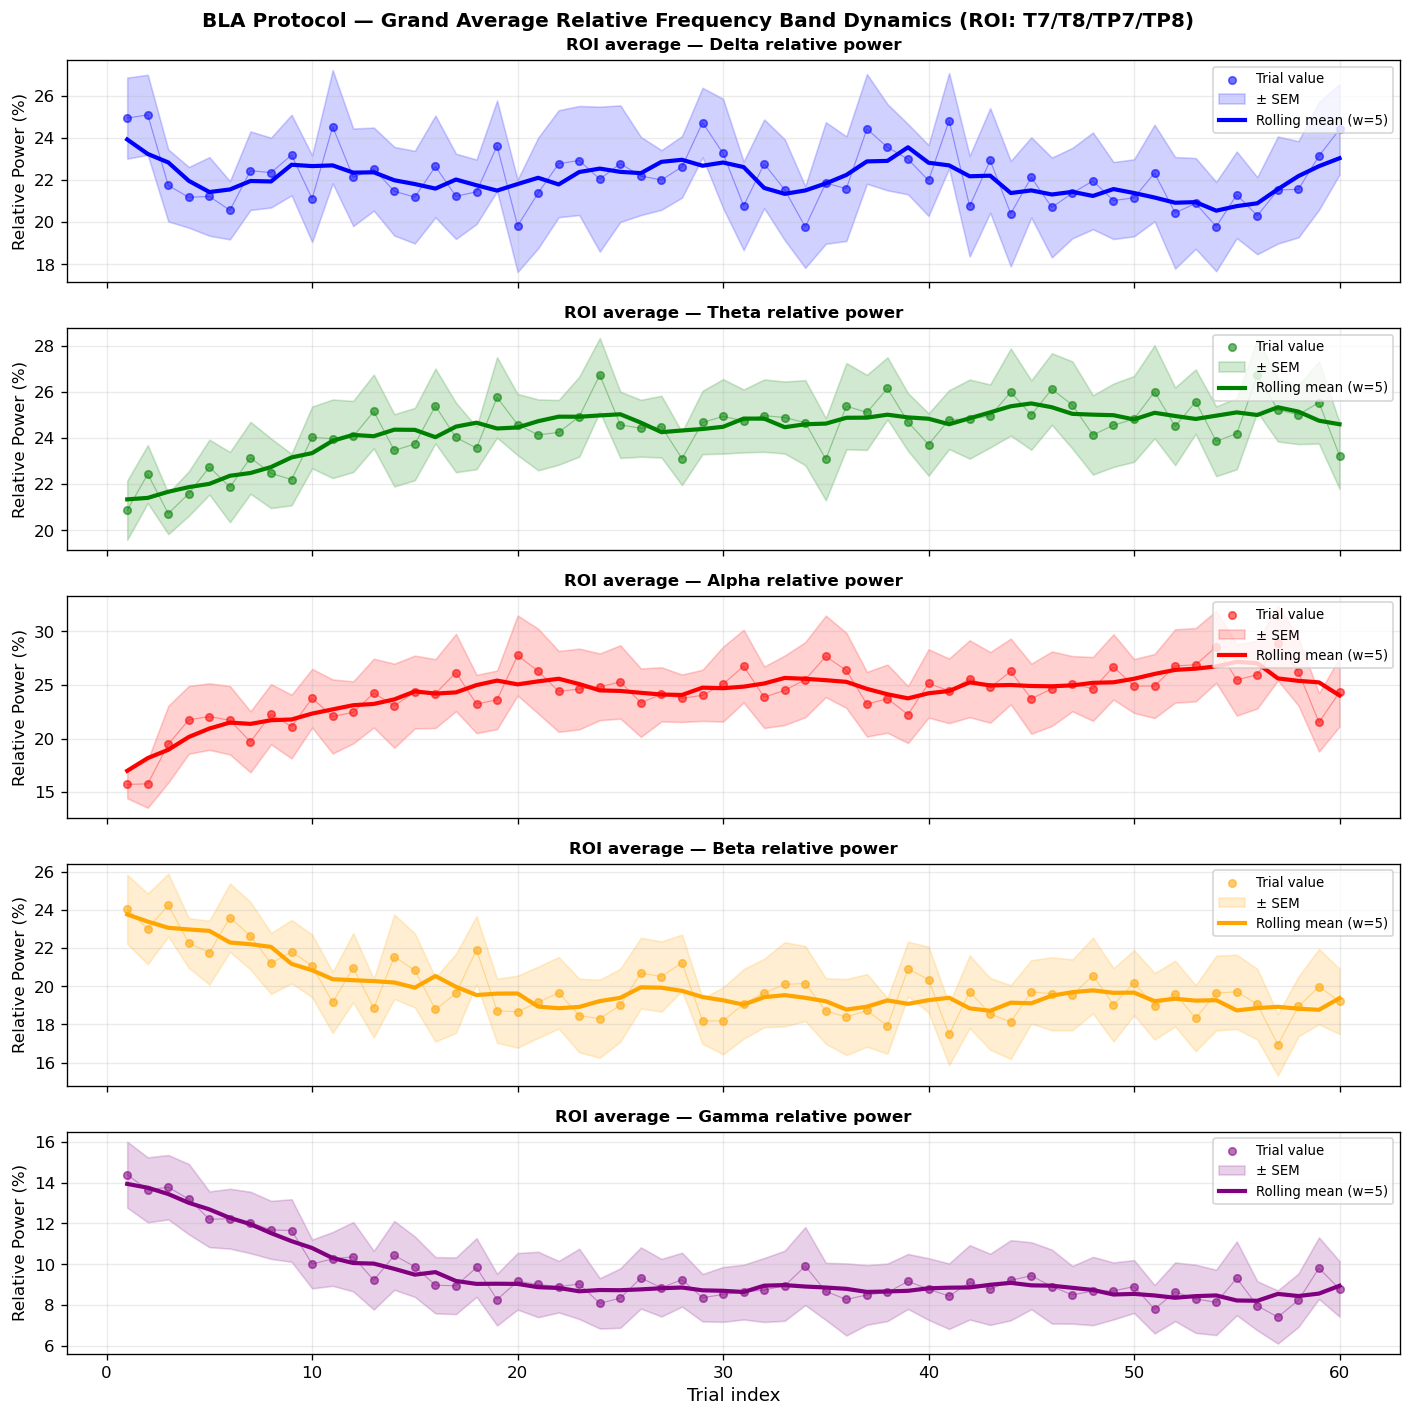

Figure saved: relative_frequency_dynamics_BLA_grand_average.png
Relative power = percent of total power across delta/theta/alpha/beta/gamma within each trial.


In [38]:
# --- Relative power grand-average plots (correctly aligned across bands) ---

bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

# Compute relative power (%) for each subject
all_relative_power_pivots = {}
relative_subject_tables = []

for subject_id in processed_subjects:
    power_pivot = all_power_pivots[subject_id].copy()

    # Force consistent band columns for every subject
    power_pivot = power_pivot.reindex(columns=bands)

    # Keep trial numbering aligned within each subject
    power_pivot = power_pivot.reset_index(drop=True)

    # Total power across the 5 bands for each trial
    total_power_per_trial = power_pivot.sum(axis=1)

    # Convert each band to percent of total trial power
    relative_power_pivot = power_pivot.div(total_power_per_trial, axis=0) * 100

    all_relative_power_pivots[subject_id] = relative_power_pivot

    # Store in long format so all 5 bands stay linked for each subject/trial row
    temp = relative_power_pivot.copy()
    temp["subject_id"] = subject_id
    temp["trial_idx"] = np.arange(1, len(temp) + 1)
    relative_subject_tables.append(temp)

# Combine all subjects
relative_long = pd.concat(relative_subject_tables, ignore_index=True)

# Grand mean and SEM across subjects, keeping all bands aligned by trial index
grand_relative_mean = relative_long.groupby("trial_idx")[bands].mean()
grand_relative_sem = relative_long.groupby("trial_idx")[bands].sem()

# Plot relative power dynamics across trials
fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

trial_idx = grand_relative_mean.index.values

for i, (band, color) in enumerate(zip(bands, colors)):
    ax = axes[i]

    values = grand_relative_mean[band].values
    errors = grand_relative_sem[band].values

    ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
    ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

    ax.fill_between(
        trial_idx,
        values - errors,
        values + errors,
        color=color,
        alpha=0.18,
        zorder=1,
        label='± SEM'
    )

    rolling = pd.Series(values).rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
    ax.plot(
        trial_idx,
        rolling,
        color=color,
        linewidth=2.5,
        zorder=3,
        label=f'Rolling mean (w={ROLLING_WINDOW})'
    )

    ax.set_ylabel('Relative Power (%)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} relative power', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    'BLA Protocol — Grand Average Relative Frequency Band Dynamics (ROI: T7/T8/TP7/TP8)',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('relative_frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: relative_frequency_dynamics_BLA_grand_average.png")
print("Relative power = percent of total power across delta/theta/alpha/beta/gamma within each trial.")



# BLA Time_Frequency Domain Absolute Power

In [40]:
# Import time-frequency functions
import mne
from mne.time_frequency import tfr_morlet

# Time-frequency analysis parameters
TF_N_CYCLES = 2.0
TF_FREQS = np.logspace(np.log10(1), np.log10(45), 20)  # 1–45 Hz, log-spaced

# Match the rest of the notebook
SUBJECTS = [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
CONDITION = "BLA"
CHANNELS = "BLA"

print("Time-frequency analysis parameters:")
print(f"Frequencies: {TF_FREQS[0]:.1f} - {TF_FREQS[-1]:.1f} Hz ({len(TF_FREQS)} points)")
print(f"Wavelet cycles: {TF_N_CYCLES}")
print(f"Analyzing {len(SUBJECTS)} subjects: {SUBJECTS}")
print(f"Condition: {CONDITION}")
print(f"Channels: {CHANNELS}")



Time-frequency analysis parameters:
Frequencies: 1.0 - 45.0 Hz (20 points)
Wavelet cycles: 2.0
Analyzing 14 subjects: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]
Condition: BLA
Channels: BLA


In [46]:
import warnings
import contextlib
import io

# Compute time-frequency representations for each subject
tf_power_dfs = {}
tf_power_pivots = {}
tf_processed_subjects = []
tf_failed_subjects = []

for subject_id in SUBJECTS:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                epochs = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band="delta_gamma"
                )

                # Get data in µV
                data = epochs.get_data() * 1e6

                # Apply baseline correction
                baseline_mask = (epochs.times >= -0.200) & (epochs.times <= 0.000)
                baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)
                data_bc = data - baseline_mean

                n_trials, n_channels, n_times = data_bc.shape
                ch_names = epochs.ch_names

                # Put baseline-corrected data back into an Epochs object for TFR
                epochs_bc = epochs.copy()
                epochs_bc._data = data_bc / 1e6   # convert back to volts for MNE

                # Compute TFR for each channel
                tfr_data = []
                for ch in ch_names:
                    tfr = tfr_morlet(
                        epochs_bc.copy().pick([ch]),
                        freqs=TF_FREQS,
                        n_cycles=TF_N_CYCLES,
                        average=False,
                        return_itc=False,
                        verbose=False
                    )

                    power = tfr.data ** 2
                    power_avg = power.mean(axis=1)   # remove singleton channel dimension
                    tfr_data.append(power_avg)

                # Average across ROI channels
                roi_power = np.mean(tfr_data, axis=0)   # (trials, freqs, times)

                # Keep only post-stimulus time points
                post_stim_mask = tfr.times >= 0
                times_post = tfr.times[post_stim_mask]
                roi_power_post = roi_power[:, :, post_stim_mask]

                # Extract power in frequency bands over time
                band_power_over_time = {}
                for band, (fmin, fmax) in FREQ_BANDS.items():
                    freq_mask = (TF_FREQS >= fmin) & (TF_FREQS <= fmax)
                    if freq_mask.any():
                        band_power = roi_power_post[:, freq_mask, :].mean(axis=1)
                        band_power_over_time[band] = band_power

                # Create DataFrame with time-frequency features
                tf_features = []
                for trial in range(n_trials):
                    for time_idx, time_val in enumerate(times_post):
                        row = {
                            'trial': trial + 1,
                            'time_ms': time_val * 1000
                        }
                        for band in FREQ_BANDS.keys():
                            if band in band_power_over_time:
                                row[f'{band}_power'] = band_power_over_time[band][trial, time_idx]
                        tf_features.append(row)

                tf_df = pd.DataFrame(tf_features)

                # Create pivot table: trials × time × bands
                tf_pivot = {}
                for band in FREQ_BANDS.keys():
                    col_name = f'{band}_power'
                    if col_name in tf_df.columns:
                        tf_pivot[band] = tf_df.pivot(index='trial', columns='time_ms', values=col_name)

        tf_power_dfs[subject_id] = tf_df
        tf_power_pivots[subject_id] = tf_pivot
        tf_processed_subjects.append(subject_id)

    except Exception as e:
        tf_failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", tf_processed_subjects)

if tf_failed_subjects:
    print("\nFailed:")
    for subject_id, err in tf_failed_subjects:
        print(f"Subject {subject_id}: {err}")

Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


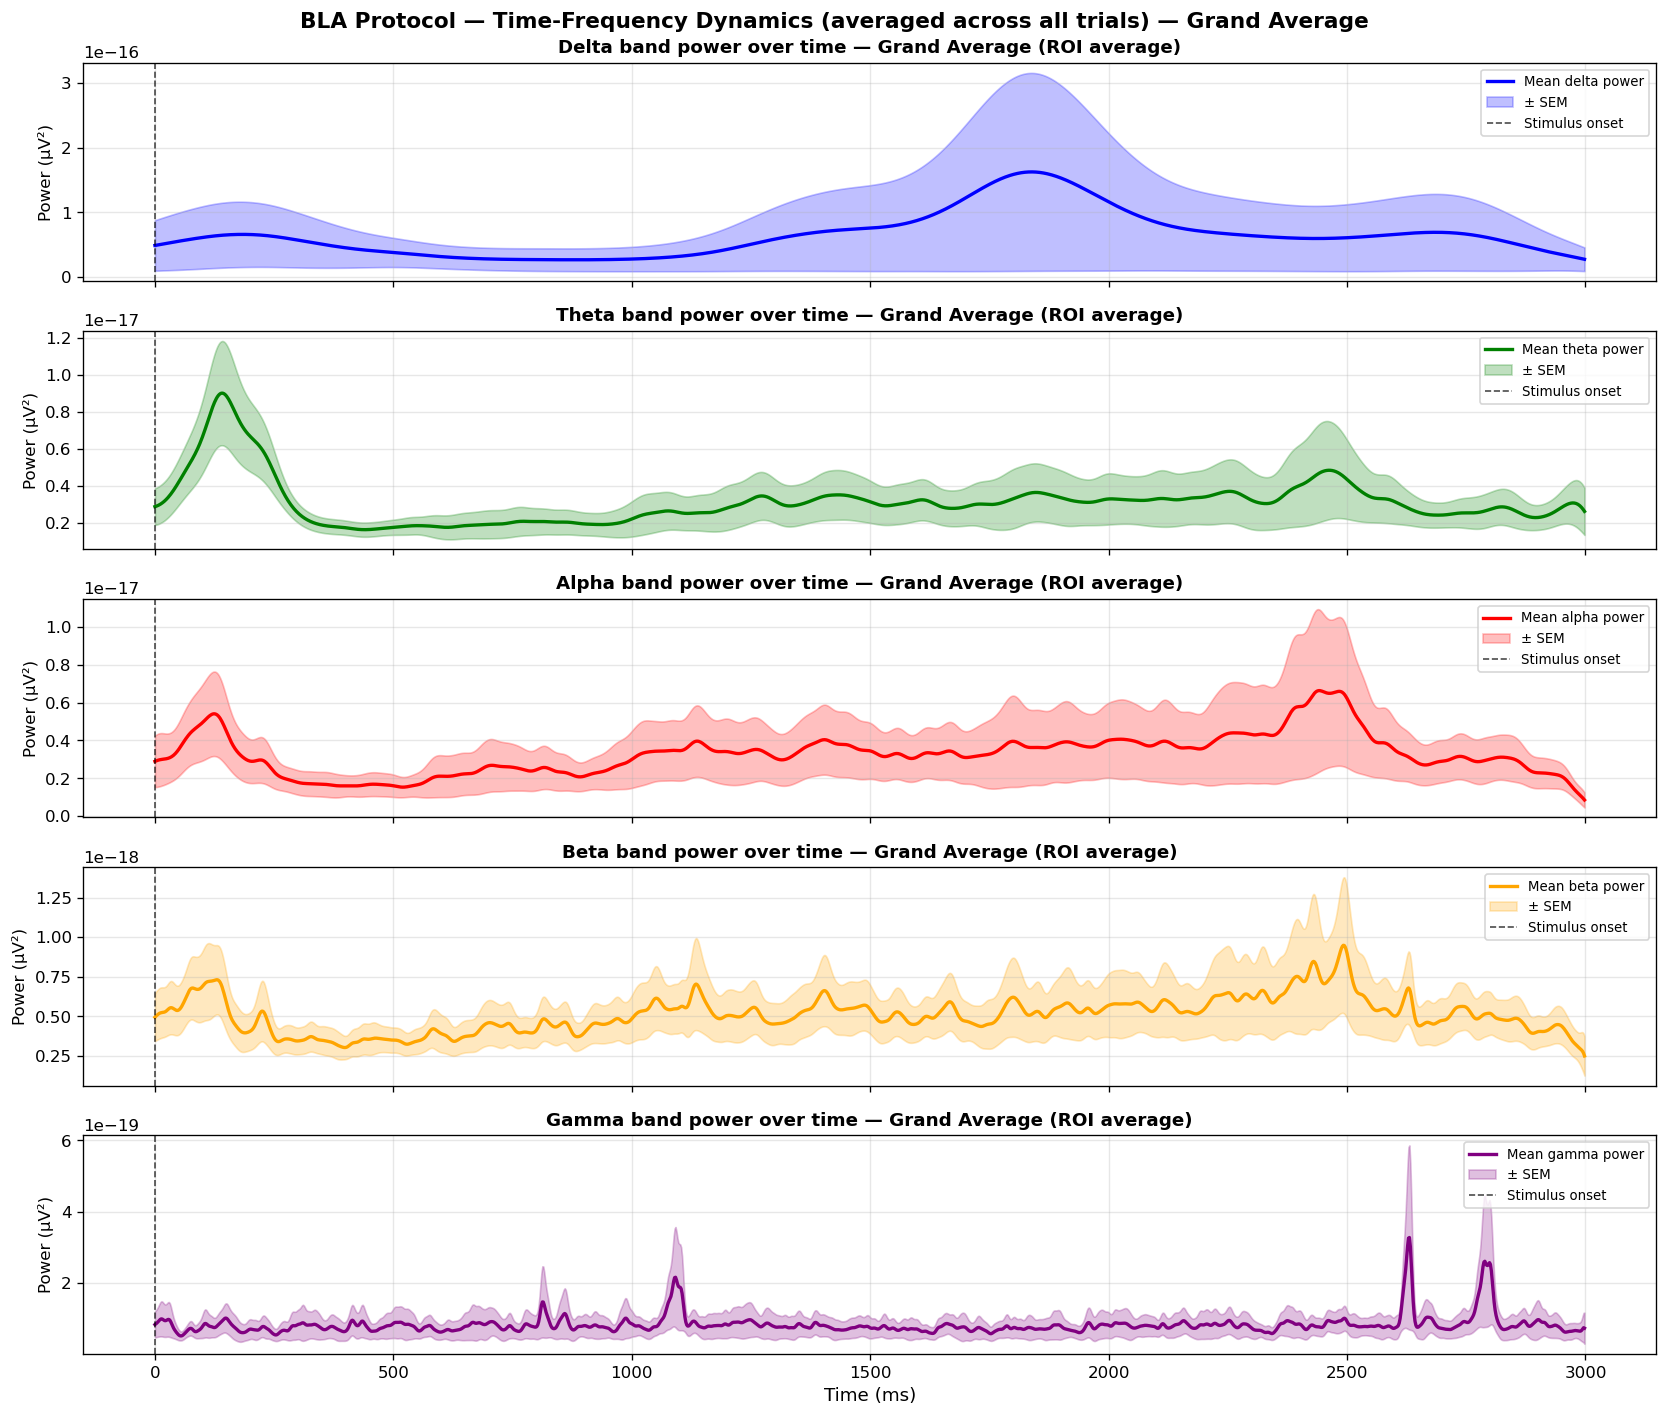

Figure saved: time_frequency_dynamics_BLA_grand_average.png


In [47]:
# Plot time-frequency power dynamics over trials (grand average across subjects)
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

grand_tf_power = {}
grand_tf_sem = {}

for band in bands:
    band_subject_means = []

    for subject_id in tf_processed_subjects:
        if subject_id in tf_power_pivots:
            tf_pivot = tf_power_pivots[subject_id]

            if band in tf_pivot:
                pivot_data = tf_pivot[band]

                # Mean over trials for this subject
                subject_mean = pivot_data.mean(axis=0)
                band_subject_means.append(subject_mean.reset_index(drop=True))

    if band_subject_means:
        band_df = pd.concat(band_subject_means, axis=1)
        grand_tf_power[band] = band_df.mean(axis=1)
        grand_tf_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

# Get time points from the first processed subject and first available band
first_subject = tf_processed_subjects[0]
available_bands = [band for band in bands if band in tf_power_pivots[first_subject]]
time_points = tf_power_pivots[first_subject][available_bands[0]].columns.values

fig, axes = plt.subplots(len(bands), 1, figsize=(14, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]

    if band in grand_tf_power:
        mean_power = grand_tf_power[band].values
        errors = grand_tf_sem[band].values

        ax.plot(time_points, mean_power, color=colors[i], linewidth=2, label=f'Mean {band} power')
        ax.fill_between(
            time_points,
            mean_power - errors,
            mean_power + errors,
            color=colors[i],
            alpha=0.25,
            label='± SEM'
        )

        # Mark stimulus onset
        ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7, label='Stimulus onset')

    ax.set_ylabel('Power (µV²)', fontsize=10)
    ax.set_title(
        f'{band.capitalize()} band power over time — Grand Average (ROI average)',
        fontsize=11,
        fontweight='bold'
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (ms)', fontsize=11)
fig.suptitle(
    'BLA Protocol — Time-Frequency Dynamics (averaged across all trials) — Grand Average',
    fontsize=13,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('time_frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: time_frequency_dynamics_BLA_grand_average.png")

# BLA Time_Frequency Domain Relative Power

In [49]:
# Compute relative power for time-frequency domain analysis
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

tf_relative_power_dfs = {}
tf_relative_power_pivots = {}
tf_relative_processed_subjects = []
tf_relative_failed_subjects = []

for subject_id in tf_processed_subjects:
    try:
        tf_pivot = tf_power_pivots[subject_id]

        # Keep only bands that actually exist for this subject
        available_bands = [band for band in bands if band in tf_pivot]

        if not available_bands:
            raise ValueError("No frequency bands found in tf_power_pivots for this subject.")

        # Build total power at each trial × time point across all available bands
        total_power_at_time = None
        for band in available_bands:
            band_pivot = tf_pivot[band].copy()
            if total_power_at_time is None:
                total_power_at_time = band_pivot.copy()
            else:
                total_power_at_time = total_power_at_time + band_pivot

        # Compute relative power for each band
        relative_tf_pivot = {}
        for band in available_bands:
            band_pivot = tf_pivot[band].copy()
            relative_power = band_pivot.div(total_power_at_time) * 100
            relative_tf_pivot[band] = relative_power

        # Optional long-format dataframe
        tf_relative_features = []
        time_points = total_power_at_time.columns.values

        for trial in total_power_at_time.index:
            for time_point in time_points:
                row = {
                    'trial': trial,
                    'time_ms': time_point
                }
                for band in available_bands:
                    row[f'{band}_relative_power'] = relative_tf_pivot[band].loc[trial, time_point]
                tf_relative_features.append(row)

        tf_relative_df = pd.DataFrame(tf_relative_features)

        tf_relative_power_dfs[subject_id] = tf_relative_df
        tf_relative_power_pivots[subject_id] = relative_tf_pivot
        tf_relative_processed_subjects.append(subject_id)

    except Exception as e:
        tf_relative_failed_subjects.append((subject_id, str(e)))

print("Processed successfully:", tf_relative_processed_subjects)

if tf_relative_failed_subjects:
    print("\nFailed:")
    for subject_id, err in tf_relative_failed_subjects:
        print(f"Subject {subject_id}: {err}")





Processed successfully: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


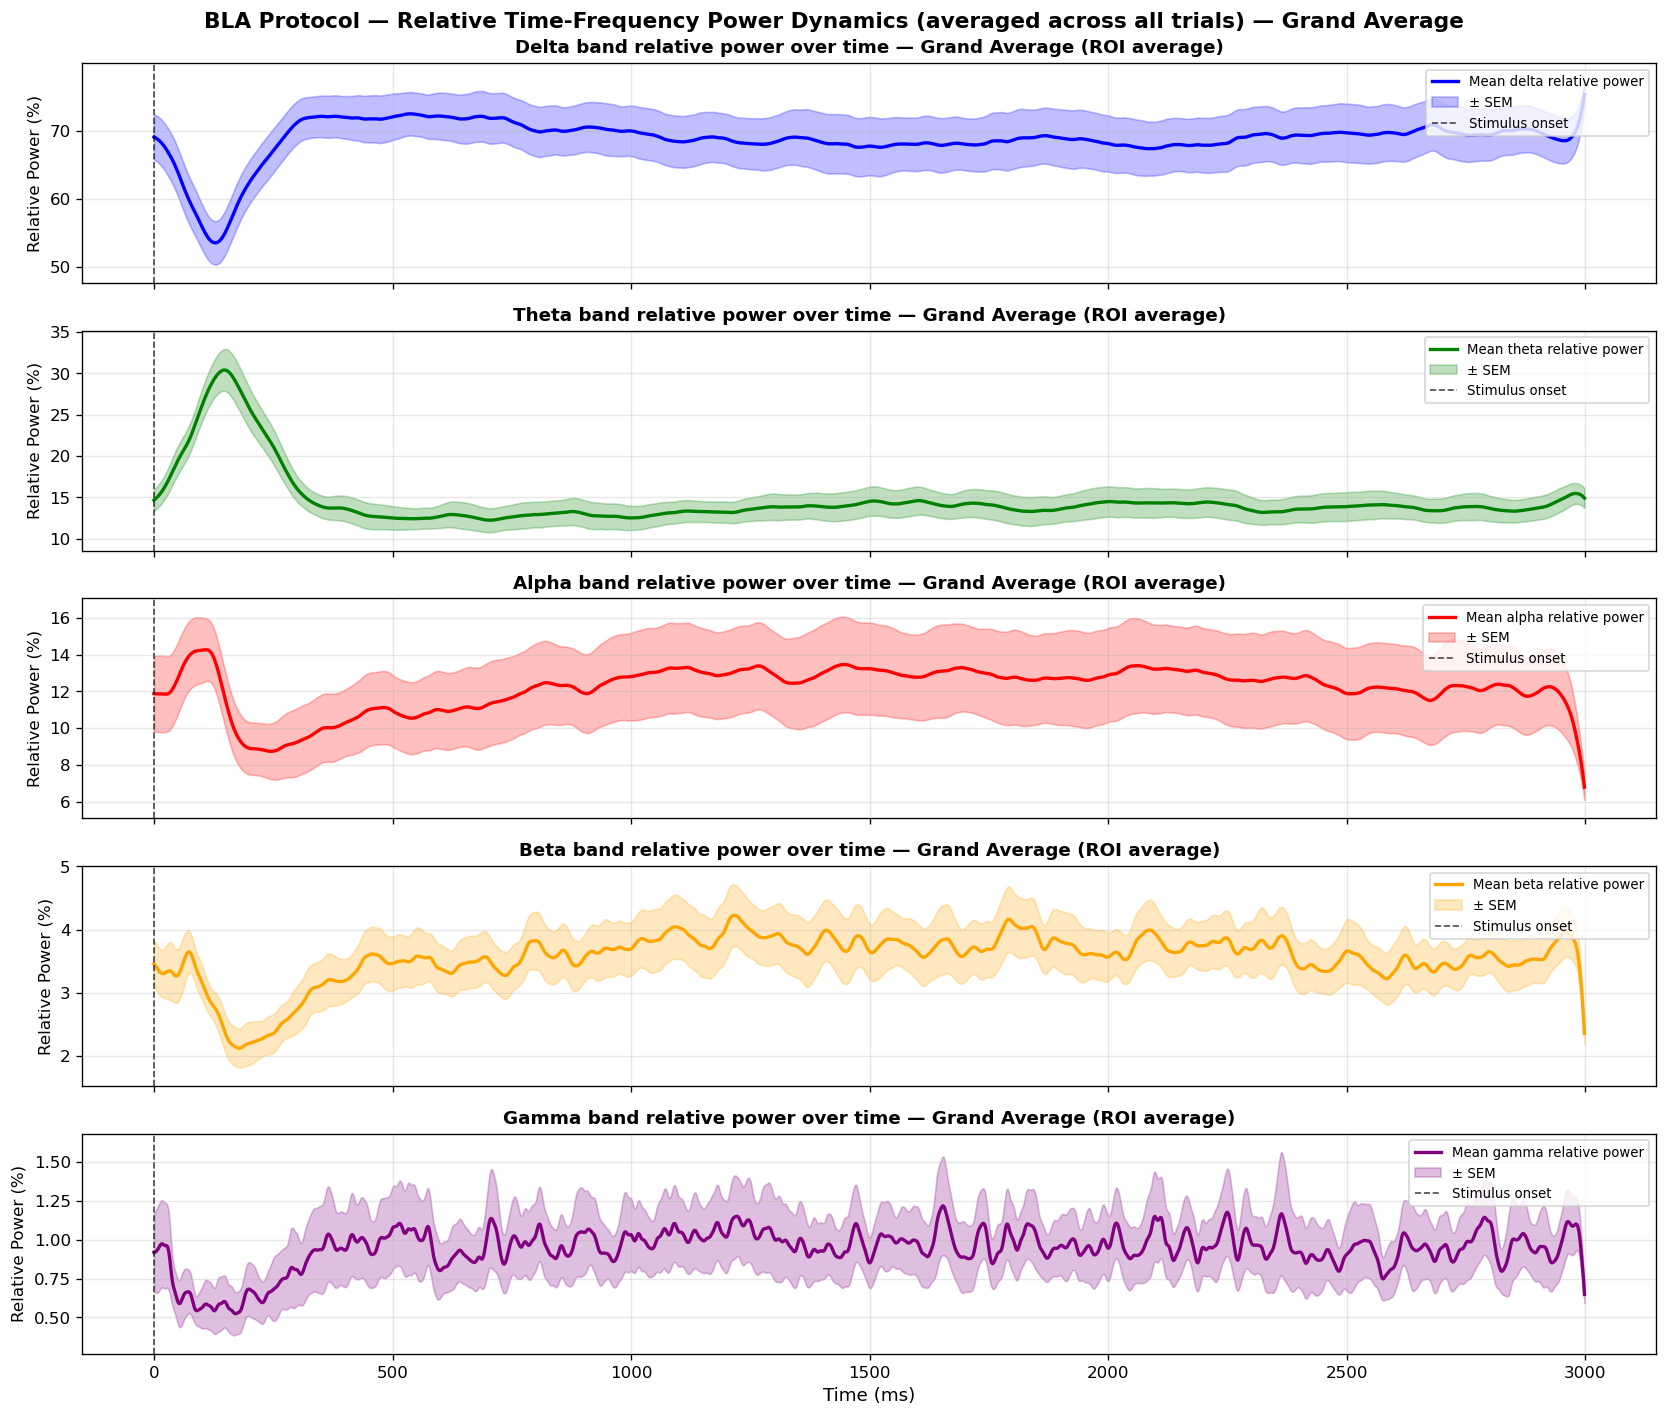

Figure saved: relative_time_frequency_dynamics_BLA_grand_average.png

Average relative power across time (Grand Average):
Delta: 68.7%
Theta: 14.6%
Alpha: 12.2%
Beta: 3.6%
Gamma: 0.9%

Grand-average summed relative power across bands:
Min: 100.000000
Max: 100.000000

First 10 time points:


0    100.0
1    100.0
2    100.0
3    100.0
4    100.0
5    100.0
6    100.0
7    100.0
8    100.0
9    100.0
dtype: float64

In [50]:
# Plot relative time-frequency power dynamics over trials (grand average across subjects)
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']
colors = ['blue', 'green', 'red', 'orange', 'purple']

grand_tf_relative_power = {}
grand_tf_relative_sem = {}

for band in bands:
    band_subject_means = []

    for subject_id in tf_relative_processed_subjects:
        if subject_id in tf_relative_power_pivots:
            tf_relative_pivot = tf_relative_power_pivots[subject_id]

            if band in tf_relative_pivot:
                pivot_data = tf_relative_pivot[band]

                # Mean over trials for this subject
                subject_mean = pivot_data.mean(axis=0)
                band_subject_means.append(subject_mean.reset_index(drop=True))

    if band_subject_means:
        band_df = pd.concat(band_subject_means, axis=1)
        grand_tf_relative_power[band] = band_df.mean(axis=1)
        grand_tf_relative_sem[band] = band_df.std(axis=1) / np.sqrt(band_df.shape[1])

# Get time points from the first processed subject and first available band
first_subject = tf_relative_processed_subjects[0]
available_bands = [band for band in bands if band in tf_relative_power_pivots[first_subject]]
time_points = tf_relative_power_pivots[first_subject][available_bands[0]].columns.values

fig, axes = plt.subplots(len(bands), 1, figsize=(14, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]

    if band in grand_tf_relative_power:
        mean_power = grand_tf_relative_power[band].values
        errors = grand_tf_relative_sem[band].values

        ax.plot(time_points, mean_power, color=colors[i], linewidth=2, label=f'Mean {band} relative power')
        ax.fill_between(
            time_points,
            mean_power - errors,
            mean_power + errors,
            color=colors[i],
            alpha=0.25,
            label='± SEM'
        )

        # Mark stimulus onset
        ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.7, label='Stimulus onset')

        # Set y-axis to fit the data properly
        min_val = np.min(mean_power - errors)
        max_val = np.max(mean_power + errors)
        pad = 0.1 * (max_val - min_val) if max_val > min_val else 1
        ax.set_ylim(min_val - pad, max_val + pad)

    ax.set_ylabel('Relative Power (%)', fontsize=10)
    ax.set_title(
        f'{band.capitalize()} band relative power over time — Grand Average (ROI average)',
        fontsize=11,
        fontweight='bold'
    )
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (ms)', fontsize=11)
fig.suptitle(
    'BLA Protocol — Relative Time-Frequency Power Dynamics (averaged across all trials) — Grand Average',
    fontsize=13,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('relative_time_frequency_dynamics_BLA_grand_average.png', bbox_inches='tight', dpi=150)
plt.show()

print("Figure saved: relative_time_frequency_dynamics_BLA_grand_average.png")

# Print average relative power across time for each band
print("\nAverage relative power across time (Grand Average):")
for band in bands:
    if band in grand_tf_relative_power:
        avg_relative_power = grand_tf_relative_power[band].mean()
        print(f"{band.capitalize()}: {avg_relative_power:.1f}%")

# Check that grand-average relative powers sum to ~100% at each time point
grand_sum = None
for band in bands:
    if band in grand_tf_relative_power:
        if grand_sum is None:
            grand_sum = grand_tf_relative_power[band].copy()
        else:
            grand_sum = grand_sum + grand_tf_relative_power[band]

print("\nGrand-average summed relative power across bands:")
print(f"Min: {grand_sum.min():.6f}")
print(f"Max: {grand_sum.max():.6f}")
print("\nFirst 10 time points:")
display(grand_sum.head(10))

Processed successfully in both: [2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 16, 17]


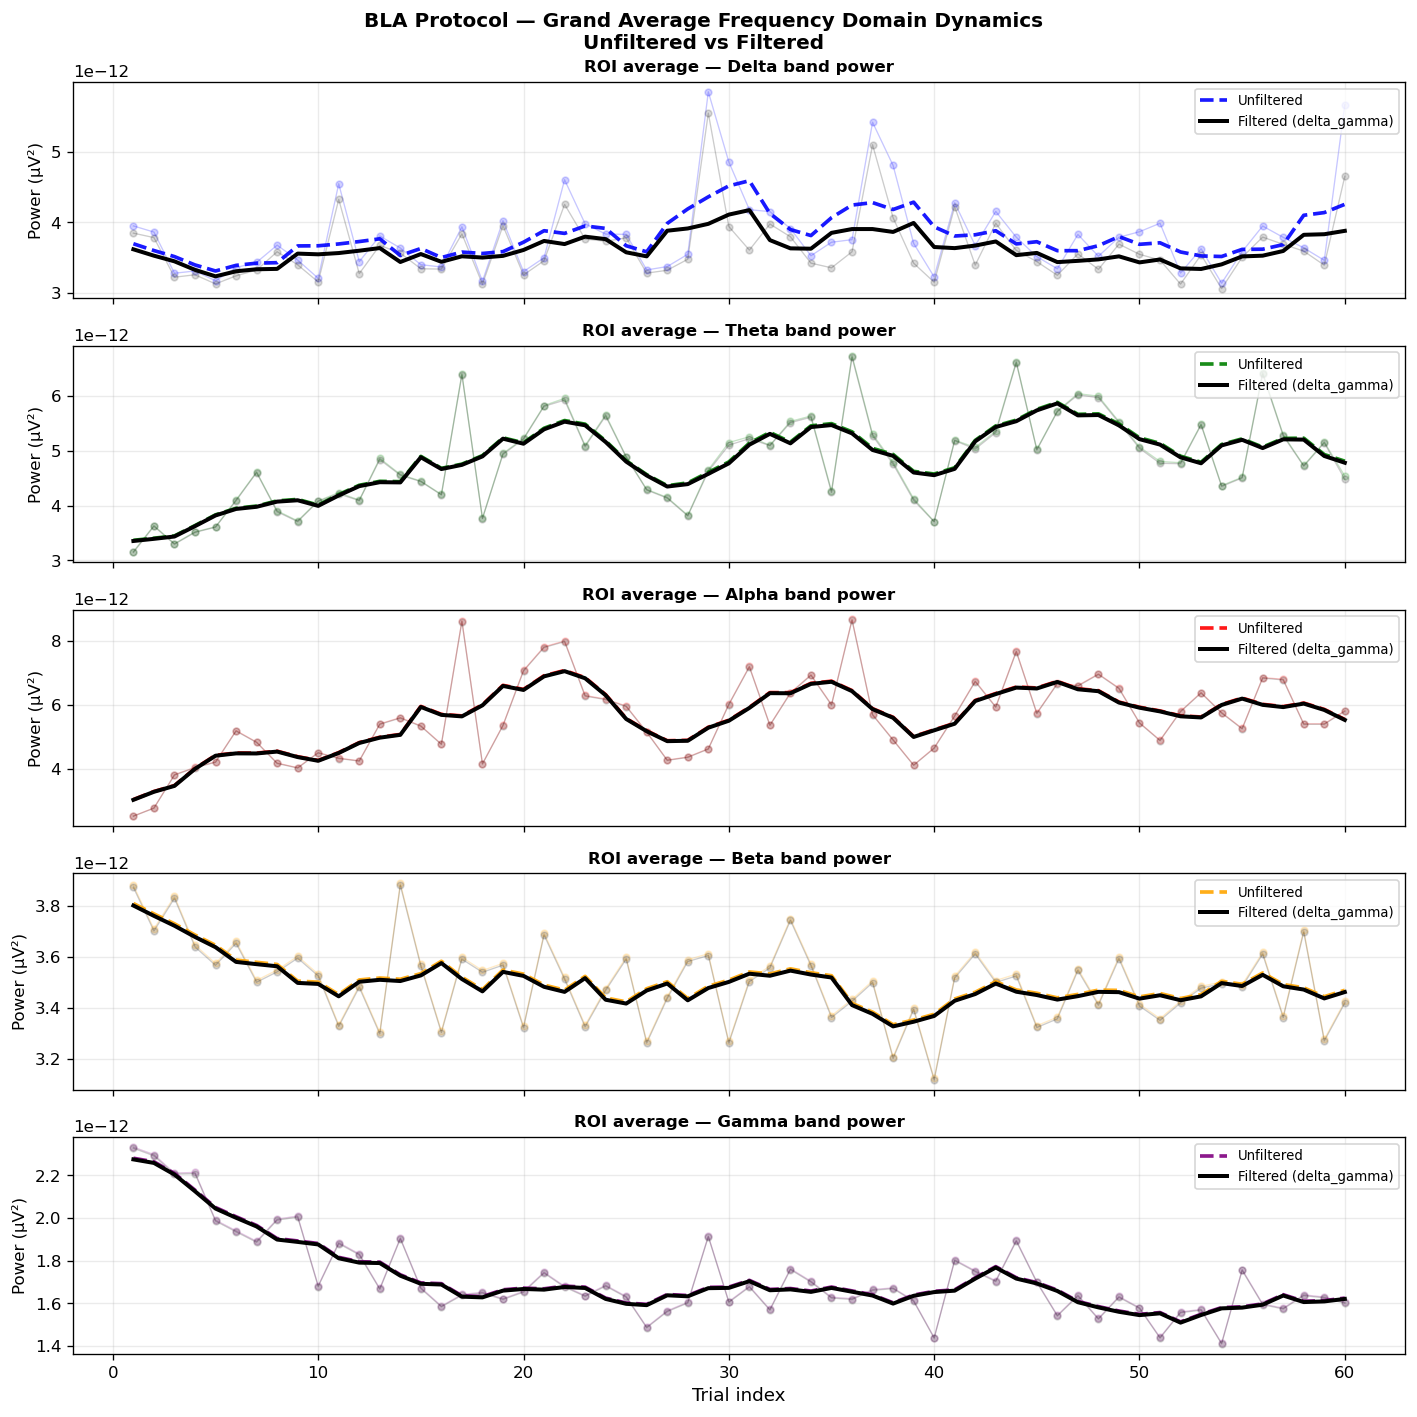


Figure saved: frequency_dynamics_BLA_filtered_vs_unfiltered.png


In [39]:
import warnings
import contextlib
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# GOAL:
# Compare grand-average band power across trials for:
#   1) unfiltered EEG data
#   2) filtered EEG data
# and plot both on the same figure.
# ------------------------------------------------------------

# Frequency bands that will appear as separate subplots
bands = ['delta', 'theta', 'alpha', 'beta', 'gamma']

# Color used for each band
colors = {
    'delta': 'blue',
    'theta': 'green',
    'alpha': 'red',
    'beta': 'orange',
    'gamma': 'purple'
}

# This is the filter applied BEFORE power is computed
# "delta_gamma" in utils corresponds to (0.5, 45) Hz
FILTER_BAND = "delta_gamma"

# ------------------------------------------------------------
# Dictionaries to store power results for each subject
# ------------------------------------------------------------

# Unfiltered results:
#   key   = subject ID
#   value = trial-by-band table of average power
all_power_pivots_unfiltered = {}

# Filtered results:
#   key   = subject ID
#   value = trial-by-band table of average power
all_power_pivots_filtered = {}

# Keep track of which subjects were successfully processed
processed_unfiltered = []
processed_filtered = []

# Keep track of any subjects that fail
failed_unfiltered = []
failed_filtered = []

# ------------------------------------------------------------
# STEP 1: For each subject, compute power twice:
#   A) once using unfiltered data
#   B) once using filtered data
# ------------------------------------------------------------

for subject_id in SUBJECTS:

    # ---------------------------
    # A) UNFILTERED DATA
    # ---------------------------
    try:
        # Suppress warning spam from MNE / utils
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load EEG data normally (no bandpass filter applied here)
                epochs_unf = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS
                )

        # Compute frequency-band power from the unfiltered epochs
        power_df_unf, _ = compute_frequency_power(epochs_unf, fmin=0.5, fmax=45)

        # Rearrange the table so:
        #   rows    = trial number
        #   columns = frequency band
        #   values  = average power across ROI channels
        power_pivot_unf = power_df_unf.groupby(['trial', 'band'])['power'].mean().unstack()

        # Save this subject's unfiltered result
        all_power_pivots_unfiltered[subject_id] = power_pivot_unf
        processed_unfiltered.append(subject_id)

    except Exception as e:
        failed_unfiltered.append((subject_id, str(e)))

    # ---------------------------
    # B) FILTERED DATA
    # ---------------------------
    try:
        # Again suppress warning spam
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):

                # Load EEG data, but this time apply the filter first
                # so ALL later calculations use the filtered signal
                epochs_filt = load_eeg_data(
                    CONDITION,
                    subject_id,
                    channels=CHANNELS,
                    freq_band=FILTER_BAND
                )

        # Compute frequency-band power from the filtered epochs
        power_df_filt, _ = compute_frequency_power(epochs_filt, fmin=0.5, fmax=45)

        # Rearrange into trial x band table
        power_pivot_filt = power_df_filt.groupby(['trial', 'band'])['power'].mean().unstack()

        # Save this subject's filtered result
        all_power_pivots_filtered[subject_id] = power_pivot_filt
        processed_filtered.append(subject_id)

    except Exception as e:
        failed_filtered.append((subject_id, str(e)))

# ------------------------------------------------------------
# STEP 2: Only compare subjects that worked in BOTH cases
# ------------------------------------------------------------

common_subjects = sorted(set(processed_unfiltered) & set(processed_filtered))

print("Processed successfully in both:", common_subjects)

if failed_unfiltered:
    print("\nUnfiltered failed:")
    for subject_id, err in failed_unfiltered:
        print(f"Subject {subject_id}: {err}")

if failed_filtered:
    print("\nFiltered failed:")
    for subject_id, err in failed_filtered:
        print(f"Subject {subject_id}: {err}")

# ------------------------------------------------------------
# STEP 3: Build grand-average trial curves across subjects
# ------------------------------------------------------------
# For each band:
#   - collect that band's trial-by-trial power from every subject
#   - average across subjects at each trial index
# ------------------------------------------------------------

grand_power_unfiltered = {}
grand_power_filtered = {}

for band in bands:
    band_trials_unf = []
    band_trials_filt = []

    for subject_id in common_subjects:
        pivot_unf = all_power_pivots_unfiltered[subject_id]
        pivot_filt = all_power_pivots_filtered[subject_id]

        # If this band exists for the subject, add it to the list
        if band in pivot_unf.columns:
            band_trials_unf.append(pivot_unf[band].reset_index(drop=True))

        if band in pivot_filt.columns:
            band_trials_filt.append(pivot_filt[band].reset_index(drop=True))

    # Combine all subjects side-by-side, then average across columns
    # so we get one grand-average curve for this band
    if band_trials_unf:
        grand_power_unfiltered[band] = pd.concat(band_trials_unf, axis=1).mean(axis=1)

    if band_trials_filt:
        grand_power_filtered[band] = pd.concat(band_trials_filt, axis=1).mean(axis=1)

# ------------------------------------------------------------
# STEP 4: Plot unfiltered and filtered curves together
# ------------------------------------------------------------

fig, axes = plt.subplots(len(bands), 1, figsize=(12, 12), sharex=True)

for i, band in enumerate(bands):
    ax = axes[i]
    color = colors[band]

    # ---------------------------
    # Plot UNFILTERED results
    # ---------------------------
    if band in grand_power_unfiltered:
        values_unf = grand_power_unfiltered[band].values
        trial_idx_unf = np.arange(1, len(values_unf) + 1)

        # Raw trial points
        ax.scatter(
            trial_idx_unf, values_unf,
            color=color, s=16, alpha=0.18, zorder=1
        )

        # Thin line connecting raw trial values
        ax.plot(
            trial_idx_unf, values_unf,
            color=color, linewidth=0.8, alpha=0.22, zorder=1
        )

        # Smoothed rolling mean to make the trend easier to see
        rolling_unf = pd.Series(values_unf).rolling(
            window=ROLLING_WINDOW, center=True, min_periods=1
        ).mean()

        ax.plot(
            trial_idx_unf, rolling_unf,
            color=color, linewidth=2.2, alpha=0.9, linestyle='--',
            zorder=3, label='Unfiltered'
        )

    # ---------------------------
    # Plot FILTERED results
    # ---------------------------
    if band in grand_power_filtered:
        values_filt = grand_power_filtered[band].values
        trial_idx_filt = np.arange(1, len(values_filt) + 1)

        # Raw trial points
        ax.scatter(
            trial_idx_filt, values_filt,
            color='black', s=16, alpha=0.15, zorder=2
        )

        # Thin line connecting raw trial values
        ax.plot(
            trial_idx_filt, values_filt,
            color='black', linewidth=0.8, alpha=0.20, zorder=2
        )

        # Smoothed rolling mean for filtered data
        rolling_filt = pd.Series(values_filt).rolling(
            window=ROLLING_WINDOW, center=True, min_periods=1
        ).mean()

        ax.plot(
            trial_idx_filt, rolling_filt,
            color='black', linewidth=2.4, zorder=4, label=f'Filtered ({FILTER_BAND})'
        )

    # Labels and formatting for each subplot
    ax.set_ylabel('Power (µV²)', fontsize=10)
    ax.set_title(f'ROI average — {band.capitalize()} band power', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

# Shared x-axis label and overall figure title
axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(
    'BLA Protocol — Grand Average Frequency Domain Dynamics\nUnfiltered vs Filtered',
    fontsize=12,
    fontweight='bold'
)

fig.tight_layout()
plt.savefig('frequency_dynamics_BLA_filtered_vs_unfiltered.png', bbox_inches='tight', dpi=150)
plt.show()

print("\nFigure saved: frequency_dynamics_BLA_filtered_vs_unfiltered.png")